#  [소셜미디어] 인스타 최강 인플루언서는 누구?
*팔로워 수만 보면 안 된다! 인플루언서 영향력을 측정하는 다양한 기준*

In [ ]:
# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

# ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# ▶ 경로 설정 (※ Colab을 활성화시켰다면 보통 Colab Notebooks 폴더가 자동 생성)
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Data")
os.getcwd()

import pandas as pd
df = pd.read_csv('top_insta_influencers_data.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States


## Data Info.

| 컬럼               | desc                              | sample data | 형식        |
|-------------------|-----------------------------------|-------------|------------|
| rank              | 순위                              | 1           | integer    |
| channel_info      | 인플루언서 사용자 이름            | cristiano   | string     |
| influence_score   | 영향력 점수                       | 92          | integer    |
| posts             | 게시물 수                         | 3.3k        | string     |
| followers         | 팔로워 수                         | 475.8m      | string     |
| avg_likes         | 평균 좋아요 수                    | 8.7m        | string     |
| 60_day_eng_rate   | 최근 60일 참여율                  | 1.39%       | percentage |
| new_post_avg_like | 신규 게시물 평균 좋아요 수        | 6.5m        | string     |
| total_likes       | 누적 좋아요 수                    | 29.0b       | string     |
| country           | 국가                              | Spain       | string     |


## Data Preprocessing

In [3]:
# 1. 데이터프레임 구조 확인
print("✅ 데이터 Shape:", df.shape)

# 2. 컬럼별 데이터 타입 확인
print("\n✅ 데이터 타입:")
print(df.dtypes)

# 3. 결측치 존재 여부 확인
print("\n✅ 결측치 개수:")
print(df.isnull().sum())

✅ 데이터 Shape: (200, 10)

✅ 데이터 타입:
rank                  int64
channel_info         object
influence_score       int64
posts                object
followers            object
avg_likes            object
60_day_eng_rate      object
new_post_avg_like    object
total_likes          object
country              object
dtype: object

✅ 결측치 개수:
rank                  0
channel_info          0
influence_score       0
posts                 0
followers             0
avg_likes             0
60_day_eng_rate       0
new_post_avg_like     0
total_likes           0
country              62
dtype: int64


In [4]:
# country 컬럼의 NaN 값을 'None'으로 대체
df['country'] = df['country'].fillna('None')

# 3. 결측치 존재 여부 확인
print("\n✅ 결측치 개수:")
print(df.isnull().sum())


✅ 결측치 개수:
rank                 0
channel_info         0
influence_score      0
posts                0
followers            0
avg_likes            0
60_day_eng_rate      0
new_post_avg_like    0
total_likes          0
country              0
dtype: int64


In [5]:
# 수치형 문자열을 숫자로 변환하는 함수 정의
def convert_to_number(x):
    if isinstance(x, str):
        x = x.lower().replace(',', '').strip()
        if 'k' in x:
            return float(x.replace('k', '')) * 1_000
        elif 'm' in x:
            return float(x.replace('m', '')) * 1_000_000
        elif 'b' in x:
            return float(x.replace('b', '')) * 1_000_000_000
        else:
            try:
                return float(x)
            except:
                return None
    return x

# 퍼센트 문자열을 소수로 변환
def convert_percent(x):
    if isinstance(x, str) and '%' in x:
        return float(x.replace('%', '').strip()) / 100
    return x

# 변환할 컬럼 리스트
columns_to_convert = ['posts', 'followers', 'avg_likes', 'new_post_avg_like', 'total_likes']
for col in columns_to_convert:
    df[col] = df[col].apply(convert_to_number)

# 퍼센트 변환
df['60_day_eng_rate'] = df['60_day_eng_rate'].apply(convert_percent)
df.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3300.0,475800000.0,8700000.0,0.0139,6500000.0,2.900000e+10,Spain
1,2,kyliejenner,91,6900.0,366200000.0,8300000.0,0.0162,5900000.0,5.740000e+10,United States
2,3,leomessi,90,890.0,357300000.0,6800000.0,0.0124,4400000.0,6.000000e+09,None
3,4,selenagomez,93,1800.0,342700000.0,6200000.0,0.0097,3300000.0,1.150000e+10,United States
4,5,therock,91,6800.0,334100000.0,1900000.0,0.0020,665300.0,1.250000e+10,United States


## Data EDA

### 팔로워 수는 많지만 평균 좋아요 수가 적은 계정은?

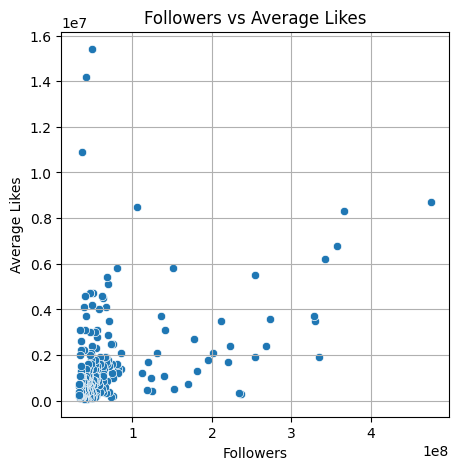

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 산점도 시각화: followers vs avg_likes
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x='followers', y='avg_likes')

plt.title("Followers vs Average Likes")
plt.xlabel("Followers")
plt.ylabel("Average Likes")
plt.grid(True)
plt.show()

In [7]:
# 상위 25% followers & 하위 25% avg_likes 기준값 계산
followers_75 = df['followers'].quantile(0.75)
likes_25 = df['avg_likes'].quantile(0.25)

# 해당 조건 만족하는 계정 필터링
low_engagement_accounts = df[(df['followers'] >= followers_75) & (df['avg_likes'] <= likes_25)]

# 주요 컬럼 출력
low_engagement_accounts[['channel_info', 'followers', 'avg_likes', 'influence_score']]

,channel_info,followers,avg_likes,influence_score
11,natgeo,237000000.0,302200.0,91
12,nike,234100000.0,329000.0,90
27,theellenshow,125100000.0,420500.0,87
30,chrisbrownofficial,118500000.0,463200.0,86
40,snoopdogg,75300000.0,203700.0,86
44,victoriassecret,73200000.0,147000.0,88
47,nba,70100000.0,370800.0,87


* 팔로워 수는 많지만 반응은 적은 계정이 존재함

### 팔로워 수가 많은 계정이 항상 높은 influence score를 가지는가?

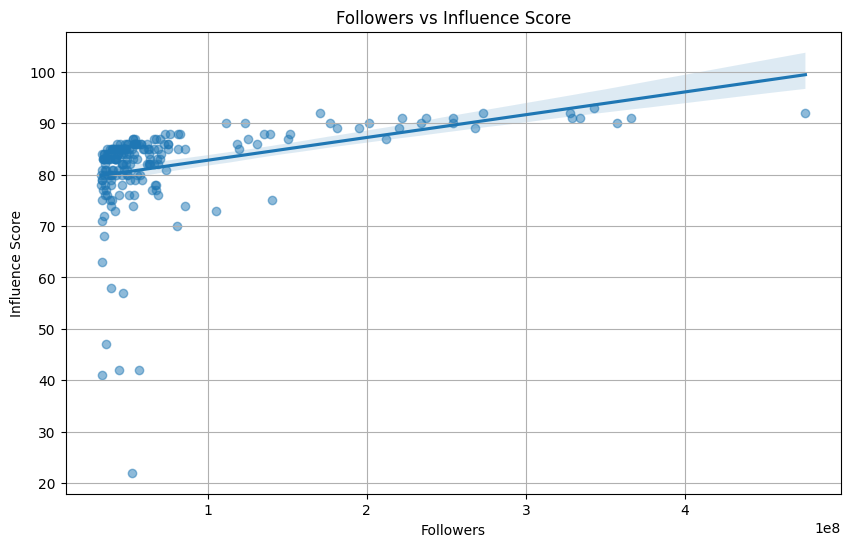

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='followers', y='influence_score', scatter_kws={'alpha':0.5})

plt.title("Followers vs Influence Score")
plt.xlabel("Followers")
plt.ylabel("Influence Score")
plt.grid(True)
plt.show()

In [9]:
correlation = df[['followers', 'influence_score']].corr().iloc[0, 1]
print(f"📌 상관계수 (followers vs influence_score): {correlation:.3f}")

📌 상관계수 (followers vs influence_score): 0.368


* 어느정도는 양의 상관관계가 존재하지만, Followers수가 적어도 높은 인플루언서 스코어를 가지고 있는 계정이 있음

In [13]:
followers_25 = df['followers'].quantile(0.25)
influence_75 = df['influence_score'].quantile(0.90)

# 예외 계정 추출
weak_influencers = df[(df['followers'] >= followers_25) & (df['influence_score'] <= influence_75)]

# 주요 정보 확인
weak_influencers[['channel_info', 'followers', 'influence_score', 'avg_likes']].head(10)

,channel_info,followers,influence_score,avg_likes
8,khloekardashian,268300000.0,89,2400000.0
14,jlo,220400000.0,89,1700000.0
15,virat.kohli,211800000.0,87,3500000.0
17,kourtneykardash,195200000.0,89,1800000.0
18,mileycyrus,181500000.0,89,1300000.0
21,kevinhart4real,152000000.0,88,522000.0
22,zendaya,150700000.0,87,5800000.0
23,iamcardib,140500000.0,75,3100000.0
24,ddlovato,139100000.0,88,1100000.0
25,badgalriri,135300000.0,88,3700000.0


### 팔로워 대비 실제 반응이 높은 인플루언서 탐색

* Engagement Rate = avg_likes / followers
→ 이 지표로 **팔로워 수에 비해 얼마나 반응(좋아요)이 좋은가?**를 확인

In [14]:
# engagement_rate 컬럼 생성
df['engagement_rate'] = df['avg_likes'] / df['followers']

In [15]:
# 참여율 기준 상위 10명
top_engaged = df.sort_values(by='engagement_rate', ascending=False).head(10)
print("✅ 참여율이 높은 인플루언서")
print(top_engaged[['channel_info', 'followers', 'avg_likes', 'engagement_rate']])

# 참여율 기준 하위 10명
low_engaged = df.sort_values(by='engagement_rate', ascending=True).head(10)
print("\n⚠️ 참여율이 낮은 인플루언서")
print(low_engaged[['channel_info', 'followers', 'avg_likes', 'engagement_rate']])


✅ 참여율이 높은 인플루언서
        channel_info   followers   avg_likes  engagement_rate
140              j.m  41900000.0  14200000.0         0.338902
102              thv  49300000.0  15400000.0         0.312373
167            rkive  37000000.0  10900000.0         0.294595
147  jenniferaniston  40700000.0   4600000.0         0.113022
155         mahi7781  39100000.0   4100000.0         0.104859
118             zayn  46500000.0   4700000.0         0.101075
114      harrystyles  46900000.0   4700000.0         0.100213
97             adele  50700000.0   4700000.0         0.092702
186      blakelively  34600000.0   3100000.0         0.089595
138       badbunnypr  42100000.0   3700000.0         0.087886

⚠️ 참여율이 낮은 인플루언서
        channel_info    followers  avg_likes  engagement_rate
11            natgeo  237000000.0   302200.0         0.001275
12              nike  234100000.0   329000.0         0.001405
134    buzzfeedtasty   43200000.0    65100.0         0.001507
44   victoriassecret   73200000.0   

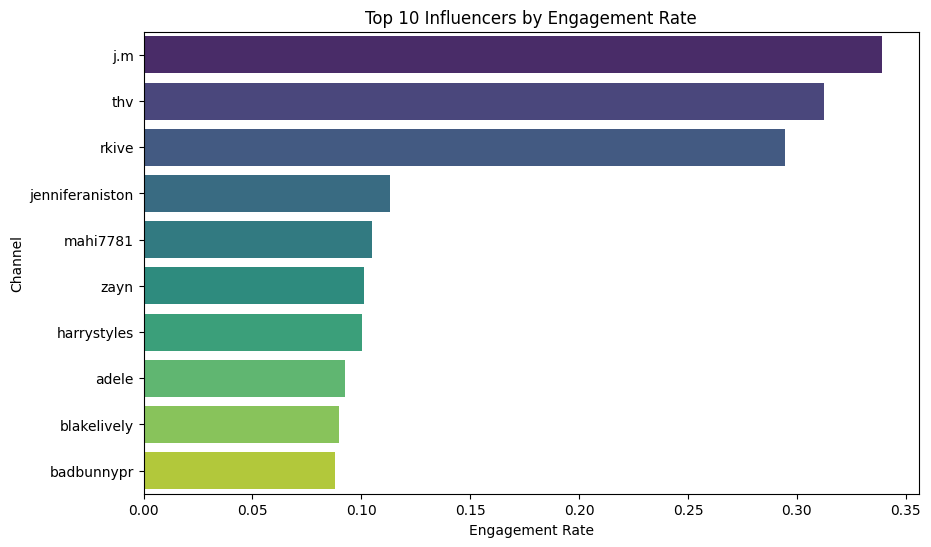

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_engaged, x='engagement_rate', y='channel_info', palette='viridis')
plt.title("Top 10 Influencers by Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Channel")
plt.show()

* 브랜드/마케팅 관점에서 “적은 팔로워도 높은 ROI 가능"

## 최강의 인플루언서의 조건은?

### HeatMap

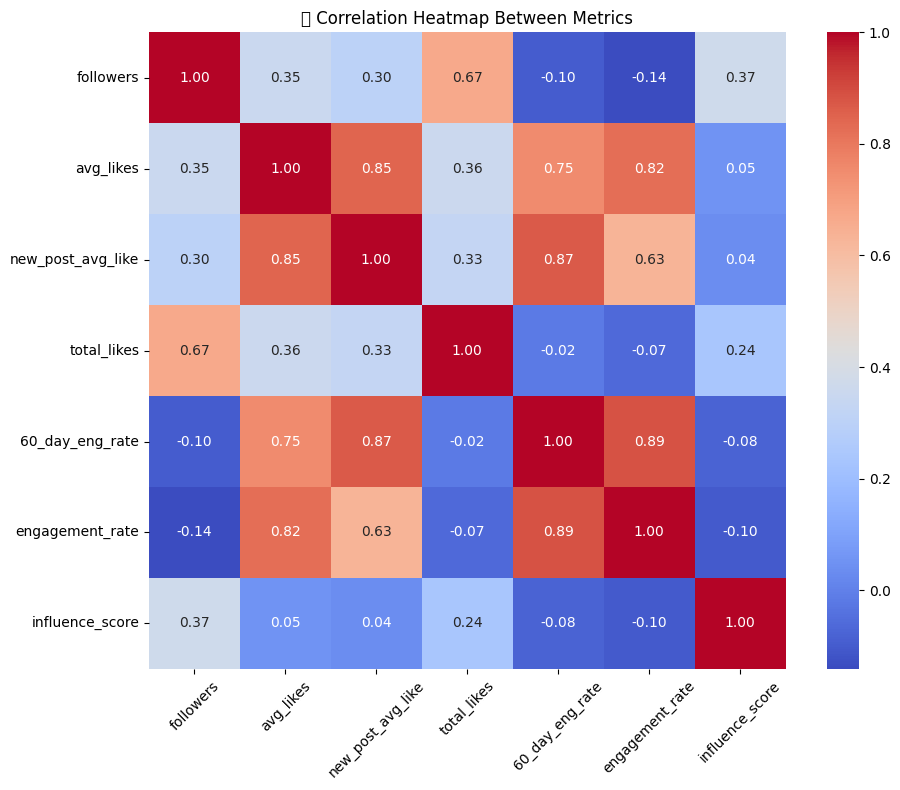

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 분석 대상 수치형 변수만 선택
numeric_cols = ['followers', 'avg_likes', 'new_post_avg_like', 'total_likes',
                '60_day_eng_rate', 'engagement_rate', 'influence_score']

# 상관계수 계산
corr_matrix = df[numeric_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)

plt.title("📊 Correlation Heatmap Between Metrics")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

* followrs와 total_likes가 양의 상관관계
* 나머지는 크게 연관성이 없음

### 회귀분석

* influence_score를 **목표 변수(y)**로 두고
나머지 주요 지표들을 **설명 변수(X)**로 설정하여 회귀 모델을 학습
* 어떤 변수가 영향력 점수에 기여하는지 파악 (feature importance)



In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. 설명 변수(X), 목표 변수(y) 정의
feature_cols = ['followers', 'avg_likes', 'new_post_avg_like', 'total_likes', '60_day_eng_rate', 'engagement_rate']
X = df[feature_cols]
y = df['influence_score']

# 2. 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 모델 학습
model = RandomForestRegressor(n_estimators=200, max_depth= 2, random_state=42)
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# 회귀 성능 평가
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✅ 모델 성능")
print(f"R² (설명력): {r2:.3f}")
print(f"MAE (평균 절대 오차): {mae:.2f}")
print(f"RMSE (평균 제곱근 오차): {rmse:.2f}")

✅ 모델 성능
R² (설명력): 0.014
MAE (평균 절대 오차): 5.44
RMSE (평균 제곱근 오차): 11.43


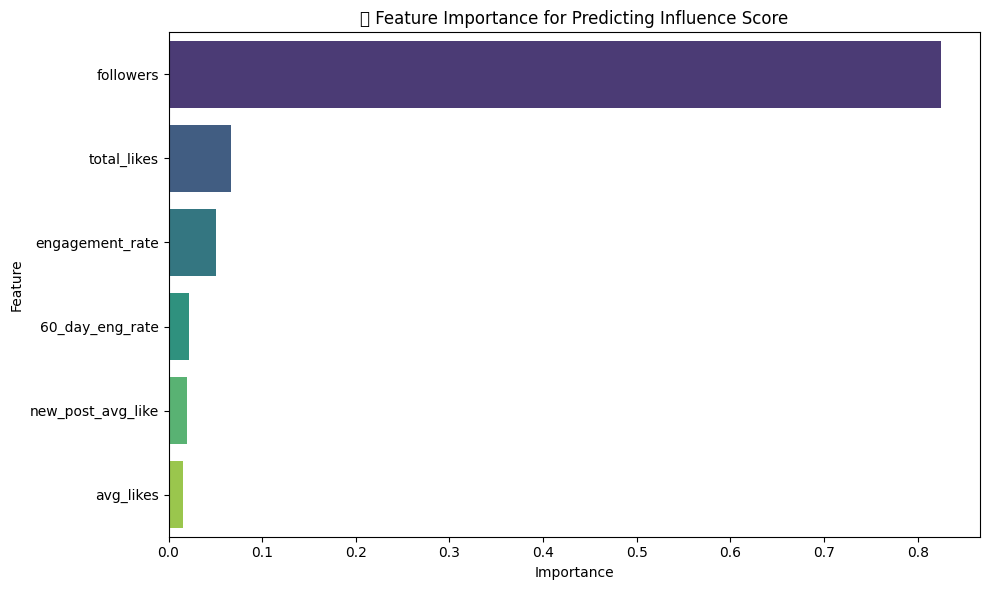

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 4. Feature Importance 추출
importances = model.feature_importances_
feat_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances}).sort_values(by='importance', ascending=False)

# 5. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df, x='importance', y='feature', palette='viridis')
plt.title("🎯 Feature Importance for Predicting Influence Score")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

* 영향력 점수는 팔로워 수가 압도적인 영향을 미치고,

* 그다음으로는 참여율, 누적 좋아요, 최근 참여율 등이 보조적으로 작용합니다.

* 반면, 최근 게시물 반응이나 평균 좋아요 수만으로는 영향력 점수를 설명하기 어렵습니다.

In [20]:
# influence_score 기준 상위 10명 추출
top_10 = df.sort_values(by='influence_score', ascending=False).head(10)

# 주요 컬럼 선택하여 보기 좋게 정리
top_10_summary = top_10[['channel_info', 'followers', 'avg_likes', 'engagement_rate',
                         '60_day_eng_rate', 'total_likes', 'influence_score']]

# 보기 좋게 정렬
top_10_summary.reset_index(drop=True, inplace=True)
display(top_10_summary)

,channel_info,followers,avg_likes,engagement_rate,60_day_eng_rate,total_likes,influence_score
0,selenagomez,342700000.0,6200000.0,0.018092,0.0097,1.150000e+10,93
1,cristiano,475800000.0,8700000.0,0.018285,0.0139,2.900000e+10,92
2,arianagrande,327700000.0,3700000.0,0.011291,0.0120,1.840000e+10,92
3,beyonce,272800000.0,3600000.0,0.013196,0.0076,7.400000e+09,92
4,katyperry,170300000.0,715000.0,0.004198,0.0016,1.500000e+09,92
5,kimkardashian,329200000.0,3500000.0,0.010632,0.0088,1.990000e+10,91
6,therock,334100000.0,1900000.0,0.005687,0.0020,1.250000e+10,91
7,kyliejenner,366200000.0,8300000.0,0.022665,0.0162,5.740000e+10,91
8,taylorswift,222200000.0,2400000.0,0.010801,0.0101,1.300000e+09,91
9,justinbieber,254500000.0,1900000.0,0.007466,0.0059,1.390000e+10,91


* 명확하게 followers 수는 또 아니다.
* 현재 데이터로 명확하게 해석할 수 없음

### “팔로워 수는 많지 않은데 influence_score가 높은 계정”

In [21]:
# 기준값 계산
followers_25 = df['followers'].quantile(0.25)
score_75 = df['influence_score'].quantile(0.65)

# 예외 케이스 필터링
low_follower_high_score = df[(df['followers'] <= followers_25) & (df['influence_score'] >= score_75)]

# 주요 정보 정리
low_follower_high_score = low_follower_high_score[['channel_info', 'followers', 'influence_score',
                                                    'avg_likes', 'engagement_rate', '60_day_eng_rate']]

print("⚡ 예외 케이스: 팔로워 수는 낮지만 influence_score가 높은 계정")
display(low_follower_high_score)


⚡ 예외 케이스: 팔로워 수는 낮지만 influence_score가 높은 계정


,channel_info,followers,influence_score,avg_likes,engagement_rate,60_day_eng_rate
149,andresiniesta8,40000000.0,85,250800.0,0.006270,0.0041
162,anushkasen0408,38300000.0,85,695400.0,0.018157,0.0175
170,gisel_la,36500000.0,85,150500.0,0.004123,0.0010
